In [1]:
from collections import defaultdict
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import numpy as np
import ast

# 2.1

First, calculate the probability (p) that makes the expected number of edges in our random network match the actual edge count in the Computational Social Scientists network. Refer to equation 3.2 in your Network Science textbook for guidance. After finding p, figure out the average degree (using the given formula).

In [15]:
df = pd.read_csv("D2_temp_papers.csv")

G = nx.Graph()
for _, row in df.iterrows():
    authors = ast.literal_eval(row["author_ids"])
    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            G.add_edge(authors[i], authors[j])

N = G.number_of_nodes()
L = G.number_of_edges()

# From eq 3.2: <L> = p * N(N-1)/2  =>  p = 2L / (N(N-1))
p = (2 * L) / (N * (N - 1))

# Average degree: <k> = p * (N - 1)
avg_degree = p * (N - 1)

print(f"Nodes (N):          {N}")
print(f"Edges (L):          {L}")
print(f"Probability p:      {p:.6f}")
print(f"Average degree <k>: {avg_degree:.4f}")

Nodes (N):          466
Edges (L):          1202
Probability p:      0.011094
Average degree <k>: 5.1588


Now, write a function to generate a Random Network that mirrors the Computational Social Scientists network in terms of node count, using your calculated p. Generate a random network by linking nodes in every possible pair with probability p. Hint: you can use the function np.random.uniform to draw samples from a uniform probability distribution.

In [8]:
def generate_random_network(N, p):
    G_random = nx.Graph()
    G_random.add_nodes_from(range(N))
    
    for i in range(N):
        for j in range(i + 1, N):
            if np.random.uniform(0, 1) < p:
                G_random.add_edge(i, j)
    
    return G_random

G_random = generate_random_network(N, p)

print(f"Random Network — Nodes: {G_random.number_of_nodes()}, Edges: {G_random.number_of_edges()}")
print(f"CSS Network    — Nodes: {N}, Edges: {L}")

Random Network — Nodes: 466, Edges: 1225
CSS Network    — Nodes: 466, Edges: 1202


Visualize the network as you did for the Computational Social Scientists network in the exercise above (my version is below).

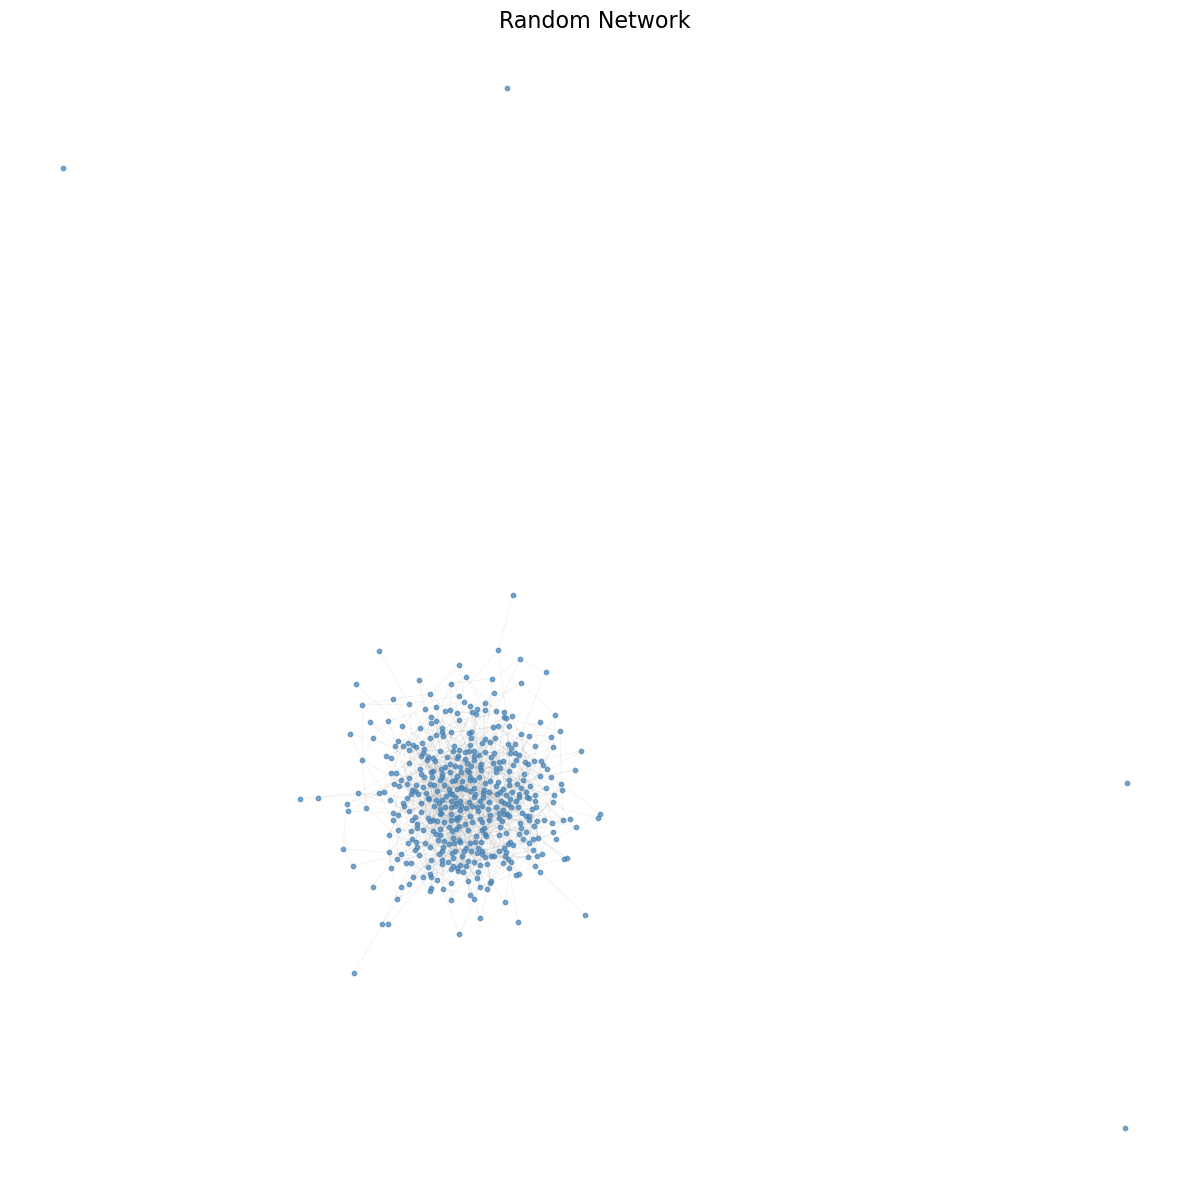

In [9]:
pos = nx.spring_layout(G_random)

plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G_random, pos, node_size=10, node_color="steelblue", alpha=0.7)
nx.draw_networkx_edges(G_random, pos, width=0.3, alpha=0.2, edge_color="gray")
plt.title("Random Network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.savefig("random_network.png", dpi=150, bbox_inches="tight")
plt.show()

Answer the following questions:
- What regime does your random network fall into? Is it above or below the critical threshold?
- According to the textbook, what does the network’s structure resemble in this regime?
- Based on your visualizations, identify the key differences between the actual and the random networks. Explain whether these differences are consistent with theoretical expectations.


We would argue that the network falls into the Supercritical Regime, since the ‹k› › 1. It is above the critical threshold standing at about 5.1588.

"This regime has the most relevance to real systems, as for the first time we have a giant component that looks like a network."

### 2.2 Degree distribution


DegreeView({'https://openalex.org/A5090665793': 8, 'https://openalex.org/A5113226689': 35, 'https://openalex.org/A5058815871': 9, 'https://openalex.org/A5040821463': 6, 'https://openalex.org/A5000679279': 79, 'https://openalex.org/A5082742221': 15, 'https://openalex.org/A5002798141': 13, 'https://openalex.org/A5031463408': 7, 'https://openalex.org/A5041923525': 8, 'https://openalex.org/A5020189261': 7, 'https://openalex.org/A5063124604': 7, 'https://openalex.org/A5056499434': 15, 'https://openalex.org/A5066696247': 2, 'https://openalex.org/A5006700143': 11, 'https://openalex.org/A5081429241': 20, 'https://openalex.org/A5078651528': 8, 'https://openalex.org/A5020533147': 5, 'https://openalex.org/A5076651767': 5, 'https://openalex.org/A5052536455': 6, 'https://openalex.org/A5021501103': 5, 'https://openalex.org/A5080265907': 47, 'https://openalex.org/A5029418921': 3, 'https://openalex.org/A5110467021': 3, 'https://openalex.org/A5001893057': 3, 'https://openalex.org/A5035398709': 5, 'http

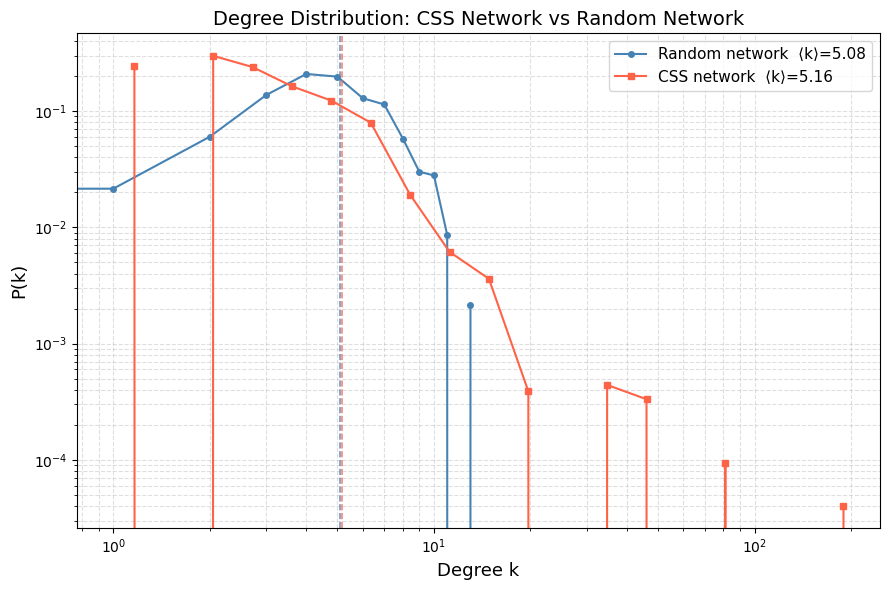

Average degree — CSS network:    5.1588
Average degree — Random network: 5.0773


In [7]:
import numpy as np

# --- Degree sequences ---
degrees_css    = np.array([d for _, d in G.degree()])
degrees_random = np.array([d for _, d in G_random.degree()])

avg_k_css    = degrees_css.mean()
avg_k_random = degrees_random.mean()

# --- Histograms ---
# Real network: heavy tail → log-spaced bins, PDF normalisation
k_min, k_max = degrees_css.min(), degrees_css.max()
bins_css = np.logspace(np.log10(max(k_min, 1)), np.log10(k_max + 1), 20)
counts_css, edges_css = np.histogram(degrees_css, bins=bins_css, density=True)
centers_css = (edges_css[:-1] + edges_css[1:]) / 2

# Random network: Poisson-like → linear bins, PDF normalisation
bins_rand = np.arange(degrees_random.min(), degrees_random.max() + 2) - 0.5
counts_rand, edges_rand = np.histogram(degrees_random, bins=bins_rand, density=True)
centers_rand = (edges_rand[:-1] + edges_rand[1:]) / 2

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(centers_rand, counts_rand, 'o-', color='steelblue',
        linewidth=1.5, markersize=4, label=f'Random network  ⟨k⟩={avg_k_random:.2f}')
ax.plot(centers_css,  counts_css,  's-', color='tomato',
        linewidth=1.5, markersize=4, label=f'CSS network  ⟨k⟩={avg_k_css:.2f}')

ax.axvline(avg_k_random, color='steelblue', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axvline(avg_k_css,    color='tomato',    linestyle='--', linewidth=1.2, alpha=0.8)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree k', fontsize=13)
ax.set_ylabel('P(k)', fontsize=13)
ax.set_title('Degree Distribution: CSS Network vs Random Network', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average degree — CSS network:    {avg_k_css:.4f}")
print(f"Average degree — Random network: {avg_k_random:.4f}")

Answer the following questions:

    Does the average degree meaningfully represents the network’s characteristics, especially in light of the insights gained from exploring heavy-tailed distributions? Discuss its adequacy or limitations in capturing the essence of the network’s structural properties.
    
    
    What differences can you observe between the real and the random distributions? How does the shape of the degree distribution for each network inform us about the network’s properties?


Average degree would misleading, as the random distribution seems to be more middle heavy, seeming like meadian also is around 5 people, while that's not the case for the real dataset.
The mean never tells about a distribution, so one should be wary of assuming that two graphs are similar, even if they share similar characteristics.


It seems like the random network, and authors dataset follow two different distributions.
While the random network is more poisson like, the the works dataset looks a lot more like a heavy tailed distribution, with it's straight line in log-log characteristic.




### 2.3 Shortest Paths: 

In [49]:
largest_cc = max(nx.algorithms.connected_components(G), key=len)

[len(c) for c in sorted(nx.connected_components(G), key=len, reverse=True)]


S = G.subgraph(largest_cc).copy()

print('size of giant component:', len(S))

print('average shortest path length:', nx.average_shortest_path_length(S))

size of giant component: 414
average shortest path length: 4.121603443637342


In [ ]:
largest_cc = max(nx.algorithms.connected_components(G_random), key=len)




S_random = G_random.subgraph(largest_cc).copy()


print('size of giant component in S_random:', len(S_random))

print('average shortest path length in S_random:', nx.average_shortest_path_length(S_random))

size of giant component in S_random: 462
average shortest path length in S_random: 3.8813420852466405


Why do you think I asked you to consider the giant component only?
Why do you think I asked you to consider unweighted edges?
Does the Computational Social Scientists network exhibit the small-world phenomenon?



We only look at giant component, to ensure the network was fully connected. 
Our mini network had in total 3 networks.

We could've used weights to quantify how much the researchers have collaborated, but in this case we were interested in the frequency, and who have been collaborating with who.

CSS dataset shows small world phenomena, as the average connectivity is only 4, like our giant dataset.

Small world behavior is < d > ~ ln(N)/ln(k) = 

In [54]:
np.log(414)/np.log(5.15) # Not far from 4.1, the random network is still close 

np.float64(3.676557689145719)